# ASH Strategy Research - Round 2

In [140]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 120})

In [142]:
# config
DATA_DIR = "../data"
DAY_LEN = 1_000_000

# prices data
prices = pd.concat(
    [pd.read_csv(f, sep=";") for f in sorted(glob.glob(f"{DATA_DIR}/prices_round_2_day_*.csv"))],
    ignore_index=True,
).sort_values(["day", "timestamp"]).reset_index(drop=True)

# trades data
trades = pd.concat(
    [pd.read_csv(f, sep=";").assign(day=int(f.split("day_")[1].split(".")[0]))
     for f in sorted(glob.glob(f"{DATA_DIR}/trades_round_2_day_*.csv"))],
    ignore_index=True,
).sort_values(["day", "timestamp"]).reset_index(drop=True)

# continuous time index 
prices["time"] = (prices["day"] - prices["day"].min()) * DAY_LEN + prices["timestamp"]
trades["time"] = (trades["day"] - trades["day"].min()) * DAY_LEN + trades["timestamp"]

# mid price and spread
prices["mid_price"] = (prices["bid_price_1"] + prices["ask_price_1"]) / 2
prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]

# ash data
ash_prices = prices[prices["product"] == "ASH_COATED_OSMIUM"].reset_index(drop=True)
ash_trades = trades[trades["symbol"] == "ASH_COATED_OSMIUM"].reset_index(drop=True)

# merge data (prices + trades)
ash_trades_wide = ash_trades.assign(i=ash_trades.groupby("time").cumcount() + 1).pivot(index="time", columns="i", values=["price", "quantity"])
ash_trades_wide.columns = [f"trade_{name}_{i}" for name, i in ash_trades_wide.columns]
ash_trades_wide = ash_trades_wide.reset_index()
ash = ash_prices.merge(ash_trades_wide, on="time", how="left")

# trade side (buy or sell)
ash["trade_side_1"] = np.where(ash["trade_price_1"] == ash["bid_price_1"], "sell", "buy")
ash["trade_side_2"] = np.where(ash["trade_price_2"] == ash["bid_price_1"], "sell", "buy")

# bid/ask level counts
ash["bid_level_count"] = ash[["bid_price_1", "bid_price_2", "bid_price_3"]].notna().sum(axis=1)
ash["ask_level_count"] = ash[["ask_price_1", "ask_price_2", "ask_price_3"]].notna().sum(axis=1)

# deepest bid/ask volume
ash["deepest_bid_volume"] = ash[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].ffill(axis=1).iloc[:, -1]
ash["deepest_ask_volume"] = ash[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].ffill(axis=1).iloc[:, -1]

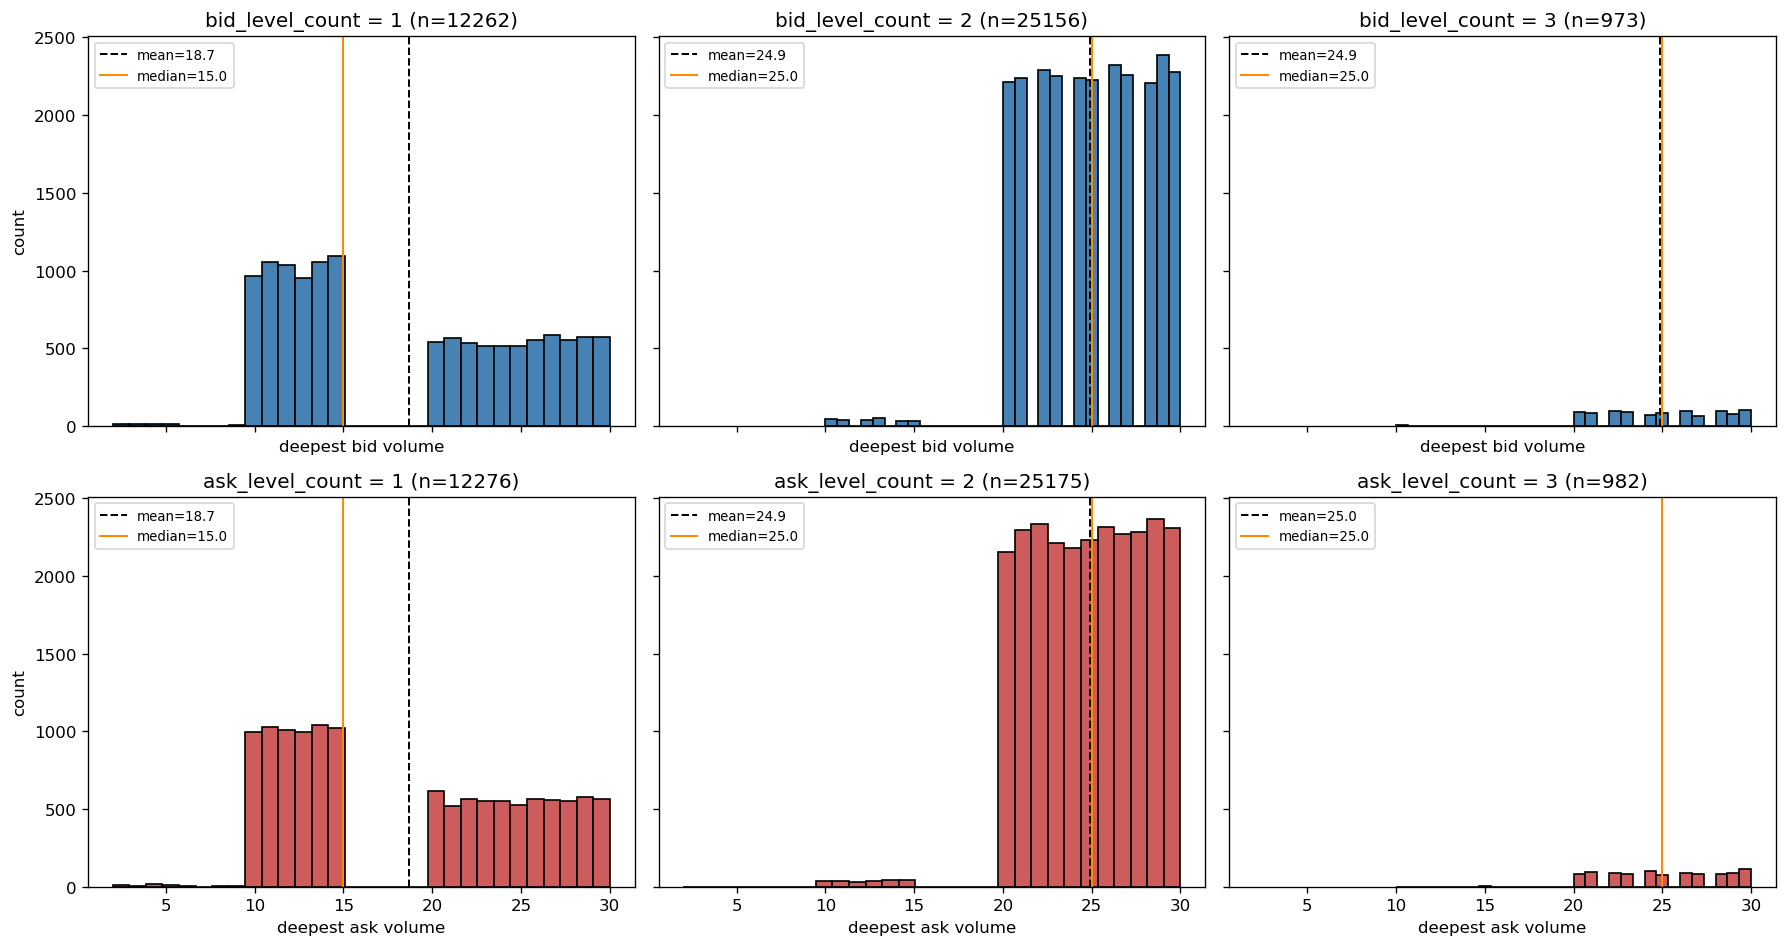

In [143]:
# deepest volume distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

def plot_hist(ax, vals, color, title, xlabel):
    ax.hist(vals, bins=30, color=color, edgecolor="black")
    m, med = vals.mean(), vals.median()
    ax.axvline(m, color="black", linestyle="--", linewidth=1.2, label=f"mean={m:.1f}")
    ax.axvline(med, color="darkorange", linestyle="-", linewidth=1.2, label=f"median={med:.1f}")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(loc="upper left", fontsize=8)

for j, c in enumerate([1, 2, 3]):
    bid_vals = ash.loc[ash["bid_level_count"] == c, "deepest_bid_volume"].dropna()
    plot_hist(axes[0, j], bid_vals, "steelblue",
              f"bid_level_count = {c} (n={len(bid_vals)})", "deepest bid volume")

    ask_vals = ash.loc[ash["ask_level_count"] == c, "deepest_ask_volume"].dropna()
    plot_hist(axes[1, j], ask_vals, "indianred",
              f"ask_level_count = {c} (n={len(ask_vals)})", "deepest ask volume")

axes[0, 0].set_ylabel("count")
axes[1, 0].set_ylabel("count")
plt.tight_layout(); plt.show()

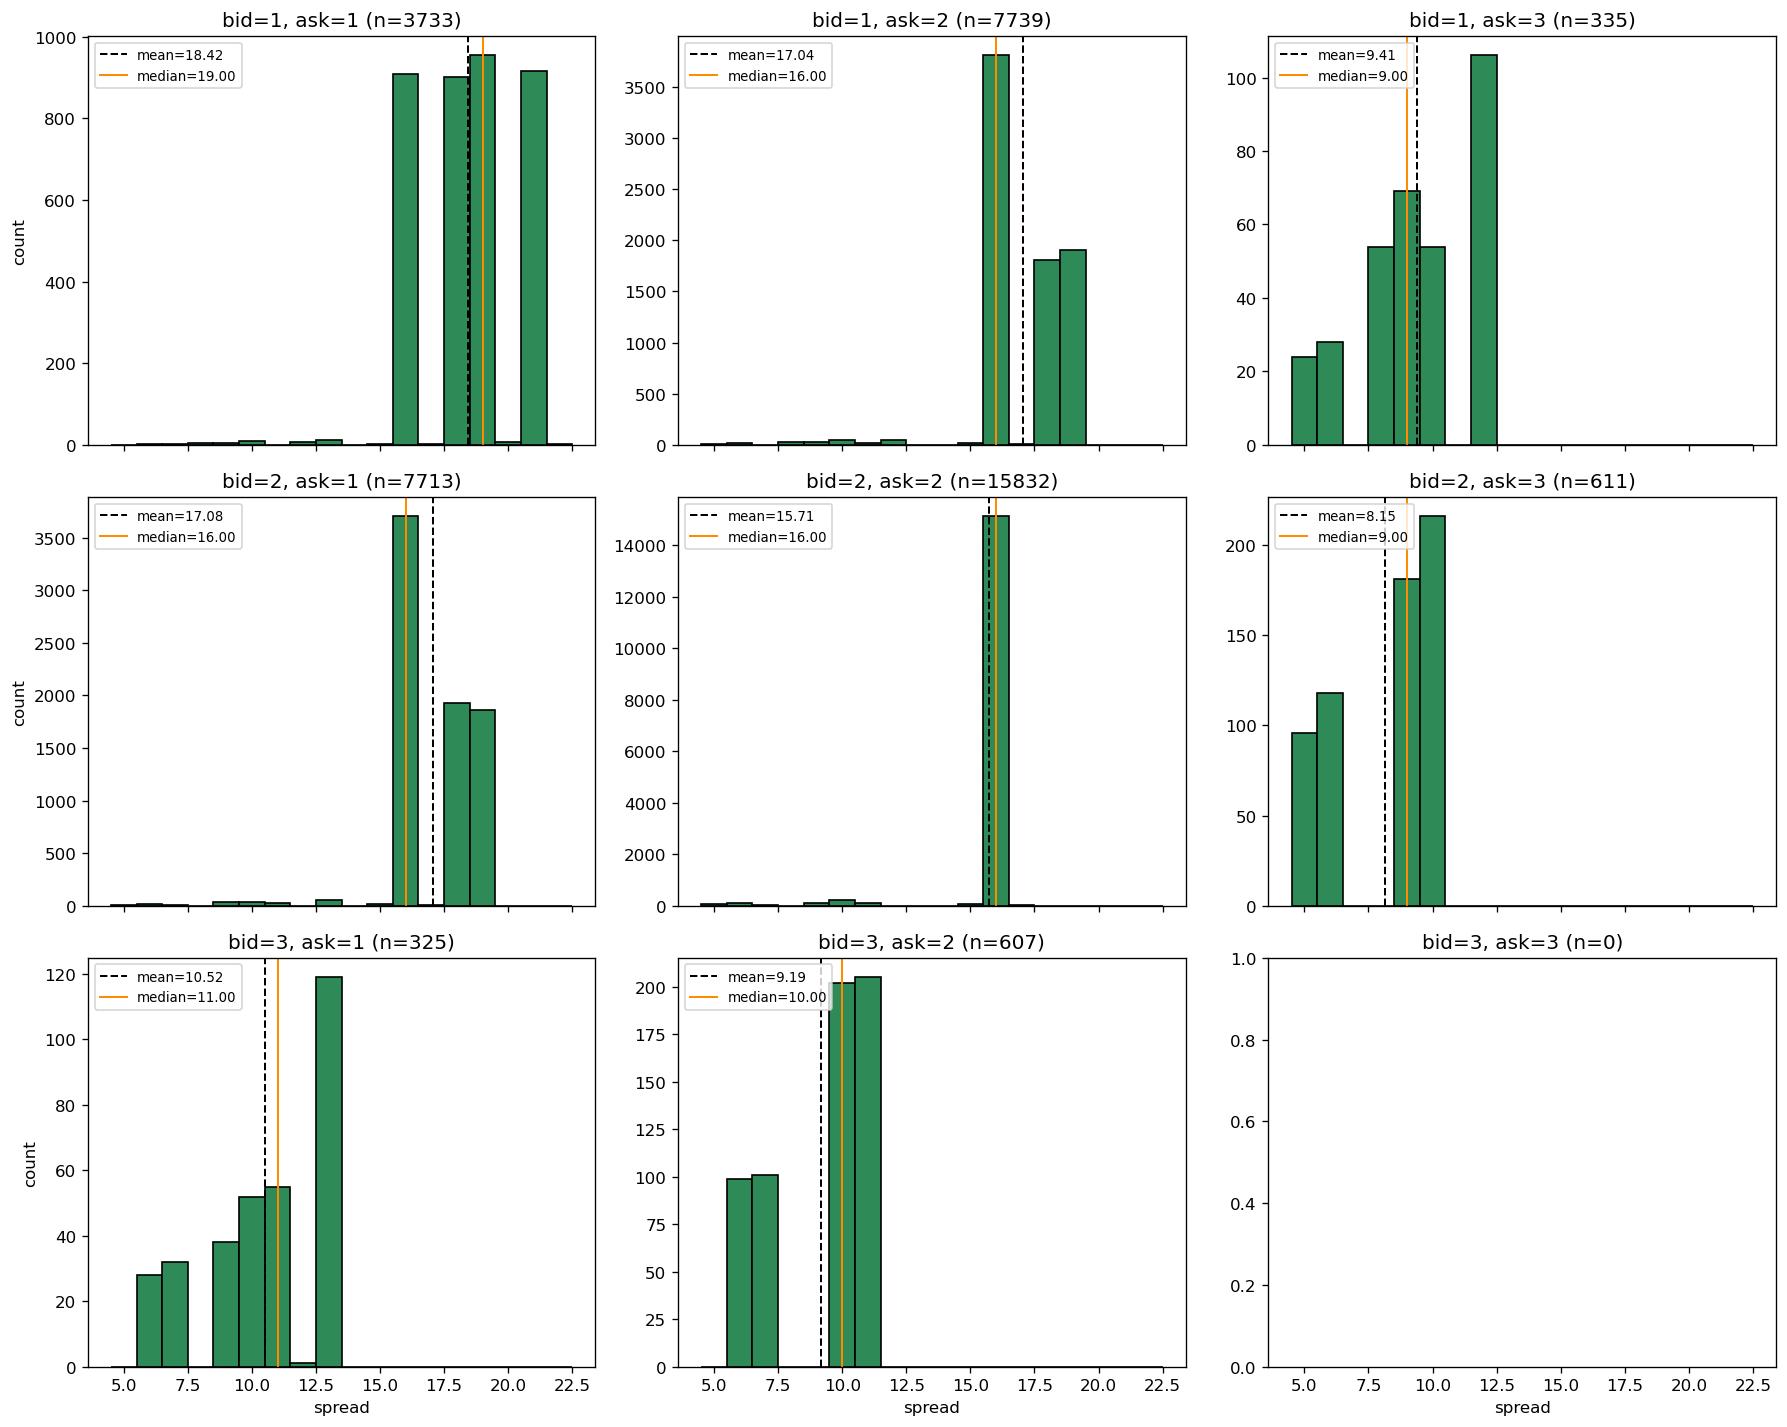

In [144]:
# spread distribution
spread_all = ash["spread"].dropna()
bins = np.arange(spread_all.min() - 0.5, spread_all.max() + 1.5, 1)

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True)
for i, bc in enumerate([1, 2, 3]):
    for j, ac in enumerate([1, 2, 3]):
        ax = axes[i, j]
        vals = ash.loc[(ash["bid_level_count"] == bc) & (ash["ask_level_count"] == ac), "spread"].dropna()
        if len(vals):
            ax.hist(vals, bins=bins, color="seagreen", edgecolor="black")
            ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.2, label=f"mean={vals.mean():.2f}")
            ax.axvline(vals.median(), color="darkorange", linestyle="-", linewidth=1.2, label=f"median={vals.median():.2f}")
            ax.legend(loc="upper left", fontsize=8)
        ax.set_title(f"bid={bc}, ask={ac} (n={len(vals)})")
        if i == 2: ax.set_xlabel("spread")
        if j == 0: ax.set_ylabel("count")
plt.tight_layout(); plt.show()

In [145]:
# wall mid price
def wall_price(row, side, min_volume):  # side = "bid" or "ask"
    for lvl in [3, 2, 1]:   # deepest first
        p, v = row.get(f"{side}_price_{lvl}"), row.get(f"{side}_volume_{lvl}")
        if pd.notna(p) and pd.notna(v) and v >= min_volume:
            return p
    return np.nan

WALL_MIN_VOLUME = 20
ash["wall_bid"] = ash.apply(lambda r: wall_price(r, "bid", WALL_MIN_VOLUME), axis=1)
ash["wall_ask"] = ash.apply(lambda r: wall_price(r, "ask", WALL_MIN_VOLUME), axis=1)
ash["wall_mid"] = (ash["wall_bid"] + ash["wall_ask"]) / 2

# consecutive-NaN distribution
is_nan = ash["wall_mid"].isna()
group_id = (~is_nan).cumsum()                 # new id each time a non-NaN appears
run_lengths = is_nan.groupby(group_id).sum()  # count NaNs per group
run_lengths = run_lengths[run_lengths > 0]    # keep only actual NaN runs
print(run_lengths.describe())

# ffill NaN wall mids
ash["wall_mid"] = ash["wall_mid"].ffill()

count    9315.000000
mean        1.551369
std         0.918178
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: wall_mid, dtype: float64


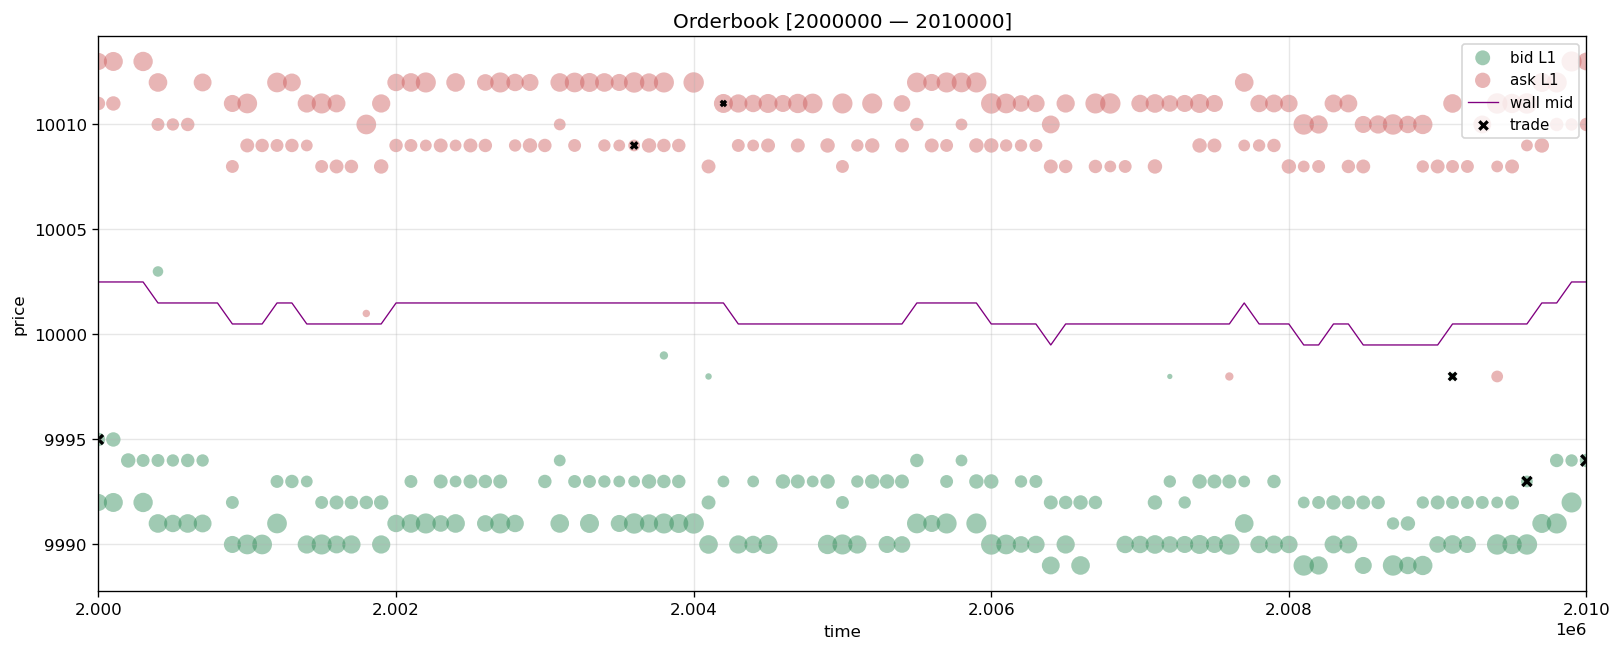

In [165]:
# orderbook and trades
def plot_orderbook(df, t_start, t_end, ax=None, show_trades=True):
    """
    Visualize the orderbook over [t_start, t_end].
    Each bid/ask level is plotted as a scatter where marker size is the resting volume.
    The mid price is overlaid as a line and executed trades are shown as X markers.
    """
    sub = df[(df["time"] >= t_start) & (df["time"] <= t_end)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 6))

    for lvl in [1, 2, 3]:
        b = sub.dropna(subset=[f"bid_price_{lvl}"])
        a = sub.dropna(subset=[f"ask_price_{lvl}"])
        ax.scatter(b["time"], b[f"bid_price_{lvl}"], s=b[f"bid_volume_{lvl}"] * 5,
                   color="seagreen", alpha=0.45, edgecolor="none",
                   label=f"bid L{lvl}" if lvl == 1 else None)
        ax.scatter(a["time"], a[f"ask_price_{lvl}"], s=a[f"ask_volume_{lvl}"] * 5,
                   color="indianred", alpha=0.45, edgecolor="none",
                   label=f"ask L{lvl}" if lvl == 1 else None)

    # ax.plot(sub["time"], sub["mid_price"], color="black", linewidth=0.8, label="raw mid")
    ax.plot(sub["time"], sub["wall_mid"], color="purple", linewidth=0.8, label="wall mid")

    if show_trades:
        for i in [1, 2]:
            tcol, qcol = f"trade_price_{i}", f"trade_quantity_{i}"
            if tcol in sub.columns:
                t = sub.dropna(subset=[tcol])
                ax.scatter(t["time"], t[tcol], s=t[qcol] * 5, marker="x",
                           color="black", linewidth=2,
                           label="trade" if i == 1 else None)

    ax.set_xlim(t_start, t_end)
    ax.set_xlabel("time"); ax.set_ylabel("price")
    ax.set_title(f"Orderbook [{t_start} — {t_end}]")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
    return ax

plot_orderbook(ash, 2_000_000, 2_010_000)
plt.show()

In [154]:
# simulate market-taking fills using a theo anchor
# position resets to 0 at the start of each day
LIMIT = 80

def simulate_fills(df, theo_col, limit=LIMIT):
    pos = 0
    positions = np.empty(len(df))
    fills = []  # (time, theo, side, price, qty)

    ask_prices  = df[[f"ask_price_{i}"  for i in [1, 2, 3]]].to_numpy()
    ask_volumes = df[[f"ask_volume_{i}" for i in [1, 2, 3]]].to_numpy()
    bid_prices  = df[[f"bid_price_{i}"  for i in [1, 2, 3]]].to_numpy()
    bid_volumes = df[[f"bid_volume_{i}" for i in [1, 2, 3]]].to_numpy()
    theos = df[theo_col].to_numpy()
    times = df["time"].to_numpy()
    days  = df["day"].to_numpy()

    prev_day = None
    for i in range(len(df)):
        if days[i] != prev_day:
            pos = 0
            prev_day = days[i]

        theo = theos[i]
        t = times[i]
        if not np.isnan(theo):
            buy_room, sell_room = limit - pos, limit + pos
            # lift asks strictly below theo
            for lvl in range(3):
                p, v = ask_prices[i, lvl], ask_volumes[i, lvl]
                if np.isnan(p) or np.isnan(v) or buy_room <= 0: continue
                if p < theo:
                    qty = min(int(v), buy_room)
                    pos += qty
                    buy_room -= qty
                    fills.append((t, theo, "buy", p, qty))
            # hit bids strictly above theo
            for lvl in range(3):
                p, v = bid_prices[i, lvl], bid_volumes[i, lvl]
                if np.isnan(p) or np.isnan(v) or sell_room <= 0: continue
                if p > theo:
                    qty = min(int(v), sell_room)
                    pos -= qty
                    sell_room -= qty
                    fills.append((t, theo, "sell", p, qty))
        positions[i] = pos

    positions_df = pd.DataFrame({"position": positions}, index=df.index)
    fills_df = pd.DataFrame(fills, columns=["time", "theo", "side", "price", "qty"])
    return positions_df, fills_df

positions, fills = simulate_fills(ash, "wall_mid")
fills.head(10)

,time,theo,side,price,qty
0,900,10000.5,buy,9998.0,8
1,8000,10004.5,sell,10006.0,6
2,21800,10006.5,buy,10004.0,8
3,23800,10005.5,buy,10003.0,7
4,24900,10004.5,sell,10006.0,4
5,32100,10003.5,sell,10005.0,10
6,32400,10003.5,sell,10005.0,10
7,36000,10004.5,sell,10006.0,10
8,41000,10004.5,buy,10002.0,6
9,41200,10004.5,buy,10002.0,10


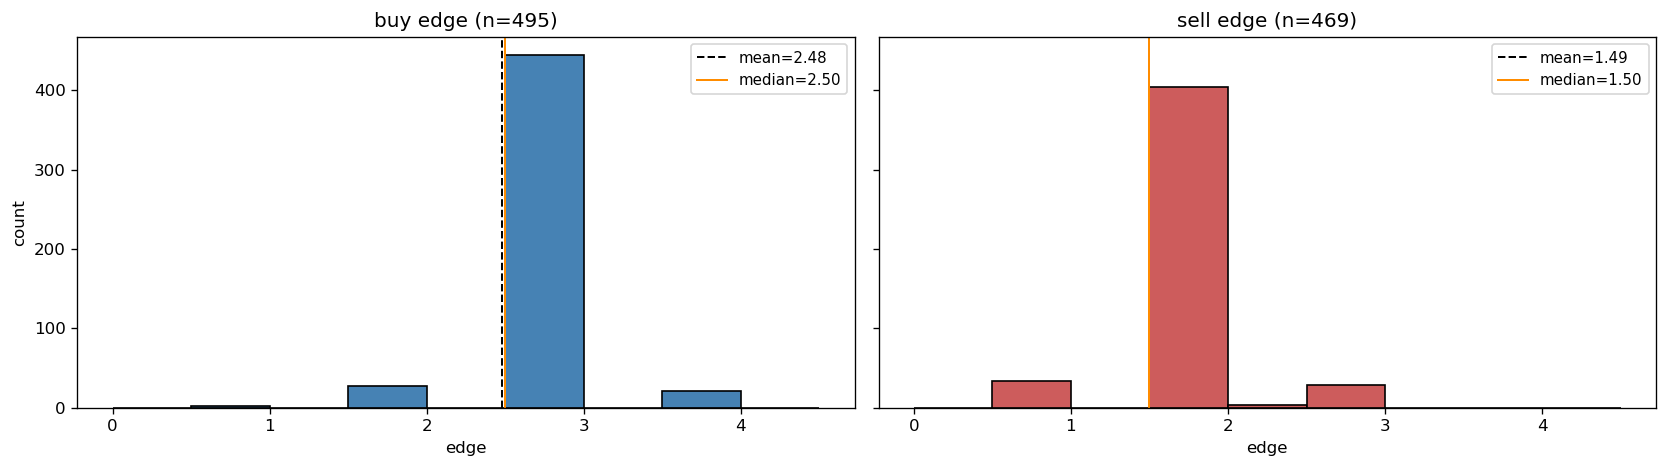

In [155]:
# edge distribution of simulated fills
fills["edge"] = np.where(
    fills["side"] == "buy",
    fills["theo"] - fills["price"],
    fills["price"] - fills["theo"],
)

buy_edge = fills.loc[fills["side"] == "buy", "edge"]
sell_edge = fills.loc[fills["side"] == "sell", "edge"]

bins = np.arange(0, fills["edge"].max() + 1.5, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, vals, color, title in [
    (axes[0], buy_edge,  "steelblue", "buy edge"),
    (axes[1], sell_edge, "indianred", "sell edge"),
]:
    ax.hist(vals, bins=bins, color=color, edgecolor="black")
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.2, label=f"mean={vals.mean():.2f}")
    ax.axvline(vals.median(), color="darkorange", linestyle="-", linewidth=1.2, label=f"median={vals.median():.2f}")
    ax.set_title(f"{title} (n={len(vals)})")
    ax.set_xlabel("edge")
    ax.legend(loc="upper right", fontsize=9)
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

       available      taken     missed   miss %
BUY         3514       3389        125     3.6%
SELL        3371       3220        151     4.5%

ticks fully blocked — buy: 14  |  sell: 14


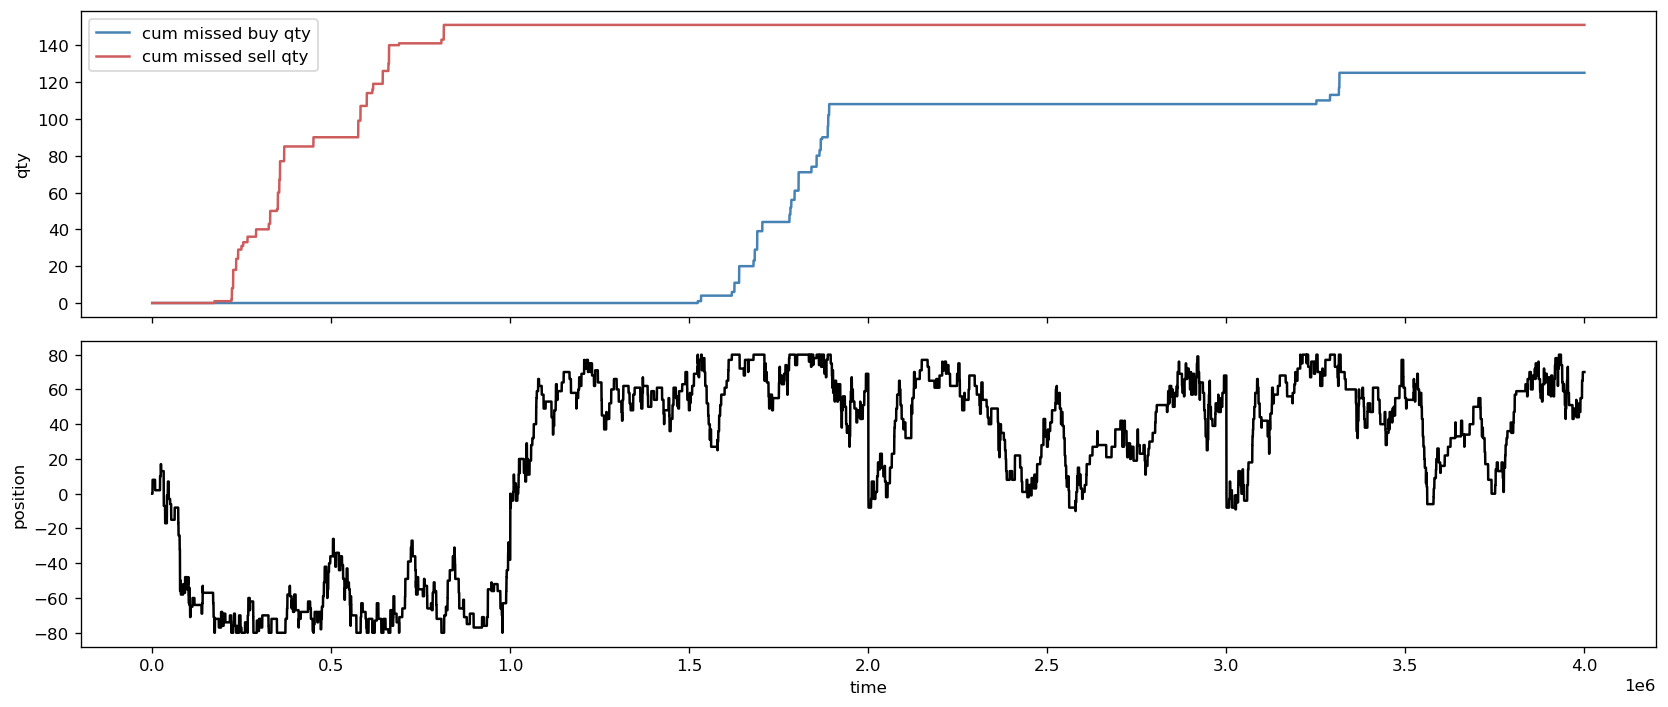

In [160]:
# opportunities left on the table due to position limit
# available = total qty on the takeable side of theo; taken = what we actually filled
ask_p = ash[[f"ask_price_{i}"  for i in [1, 2, 3]]].to_numpy()
ask_v = ash[[f"ask_volume_{i}" for i in [1, 2, 3]]].to_numpy()
bid_p = ash[[f"bid_price_{i}"  for i in [1, 2, 3]]].to_numpy()
bid_v = ash[[f"bid_volume_{i}" for i in [1, 2, 3]]].to_numpy()
theo_arr = ash["wall_mid"].to_numpy()[:, None]

avail_buy  = np.where((ask_p < theo_arr) & ~np.isnan(ask_p), np.nan_to_num(ask_v), 0).sum(axis=1)
avail_sell = np.where((bid_p > theo_arr) & ~np.isnan(bid_p), np.nan_to_num(bid_v), 0).sum(axis=1)

taken = (fills.groupby(["time", "side"])["qty"].sum().unstack(fill_value=0).reindex(ash["time"], fill_value=0))
taken_buy  = taken.get("buy",  pd.Series(0, index=ash["time"])).to_numpy()
taken_sell = taken.get("sell", pd.Series(0, index=ash["time"])).to_numpy()

missed_buy  = avail_buy  - taken_buy
missed_sell = avail_sell - taken_sell

tot_avail_buy,  tot_avail_sell  = avail_buy.sum(),  avail_sell.sum()
tot_taken_buy,  tot_taken_sell  = taken_buy.sum(),  taken_sell.sum()
tot_missed_buy, tot_missed_sell = missed_buy.sum(), missed_sell.sum()

print(f"{'':5} {'available':>10} {'taken':>10} {'missed':>10} {'miss %':>8}")
print(f"{'BUY':5} {tot_avail_buy:>10.0f} {tot_taken_buy:>10.0f} {tot_missed_buy:>10.0f} {tot_missed_buy/tot_avail_buy:>8.1%}")
print(f"{'SELL':5} {tot_avail_sell:>10.0f} {tot_taken_sell:>10.0f} {tot_missed_sell:>10.0f} {tot_missed_sell/tot_avail_sell:>8.1%}")

ticks_blocked_buy  = ((avail_buy > 0)  & (taken_buy == 0)).sum()
ticks_blocked_sell = ((avail_sell > 0) & (taken_sell == 0)).sum()
print(f"\nticks fully blocked — buy: {ticks_blocked_buy}  |  sell: {ticks_blocked_sell}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ash["time"], np.cumsum(missed_buy),  color="steelblue", label="cum missed buy qty")
axes[0].plot(ash["time"], np.cumsum(missed_sell), color="indianred", label="cum missed sell qty")
axes[0].set_ylabel("qty")
axes[0].legend()
axes[1].plot(ash["time"], positions["position"], color="black")
axes[1].set_ylabel("position")
axes[1].set_xlabel("time")
plt.tight_layout()
plt.show()

In [167]:
ash.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss', 'time',
       'spread', 'trade_price_1', 'trade_price_2', 'trade_quantity_1',
       'trade_quantity_2', 'trade_side_1', 'trade_side_2', 'bid_level_count',
       'ask_level_count', 'deepest_bid_volume', 'deepest_ask_volume',
       'wall_bid', 'wall_ask', 'wall_mid'],
      dtype='object')

In [170]:
cols = ["time", "wall_mid", "bid_level_count", "ask_level_count", "spread", "trade_price_1", "trade_quantity_1", "trade_side_1"]
ash[ash["trade_price_1"].notna()][cols].head(30)

,time,wall_mid,bid_level_count,ask_level_count,spread,trade_price_1,trade_quantity_1,trade_side_1
7,700,10000.5,1,1,21.0,9990.0,6.0,sell
9,900,10000.5,2,3,5.0,9998.0,2.0,buy
25,2500,10002.5,1,1,19.0,10011.0,8.0,buy
61,6100,10004.5,2,2,16.0,10013.0,8.0,buy
129,12900,10008.5,2,0,NaN,10001.0,9.0,sell
138,13800,10008.5,1,2,19.0,10017.0,3.0,buy
150,15000,10007.5,1,2,16.0,10016.0,3.0,buy
151,15100,10007.5,2,2,16.0,10016.0,5.0,buy
159,15900,10005.5,1,2,19.0,9995.0,9.0,sell
174,17400,10006.0,2,2,16.0,10014.0,4.0,buy
